In [1]:
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
protein_localization = np.load( path + 'protein_localization_dataset.npz')

In [3]:
investigate_dataset(protein_localization)

['X', 'y', 'genes']

Array shapes:


X shape: (9769, 12288, 6)
y shape: (9769, 12)
genes shape: (9769,)

First few y values: [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 0. 1. 0. 0.]


In [4]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(protein_localization['X'], protein_localization['genes'], n_components=1024)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (9769, 1024)


In [5]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 47.45%


In [6]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, protein_localization['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856842,-3.786984,17.809830,9.046393,-4.546642,1.068197,-10.573192,-3.584287,-7.779870,4.624094,...,-0.511404,-0.434792,0.650700,0.361658,-0.104772,0.225190,-0.533450,-1.575778,-0.366478,0.616624
FGR,-10.732205,16.028667,-5.620899,-0.390538,0.571293,-7.165012,-3.194618,0.394385,5.180049,1.700044,...,0.129070,0.836531,-0.789606,0.073719,0.208798,0.237713,0.742987,-0.485418,0.092305,-0.510226
CFH,7.006786,23.785252,-7.231864,9.518258,5.971778,5.527267,2.496928,-2.941053,-10.176261,6.325794,...,0.394056,0.367252,-0.249112,1.401372,2.195132,0.429269,1.407279,-0.867396,-1.090287,-0.667730
GCLC,3.741434,16.818712,-5.728404,10.611620,1.751277,1.134430,0.392544,2.120316,-4.206386,-1.344676,...,-0.478382,2.125103,-1.133000,-0.269638,0.873943,0.097293,0.535884,0.259269,0.158442,-2.384382
NFYA,16.261398,-2.448944,11.577354,-1.681737,-6.334037,6.196217,9.164398,2.846493,6.783405,-1.467608,...,0.619650,1.043143,-1.874604,1.071954,-0.787568,-0.699992,-1.491090,-1.545541,0.674575,-2.572969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164537,-0.711302,3.695401,-9.967203,-3.281986,2.941755,5.237513,-5.229287,-4.926545,-3.050498,...,-0.291283,-0.318109,-0.161271,-0.156971,0.137546,0.220004,0.165344,-0.153795,0.237115,0.047878
H2AC19,-16.295776,-2.631293,-1.827571,-9.977585,-2.928244,5.729977,-1.168689,-5.806112,-4.658228,-2.984133,...,-0.064520,-0.463283,0.157209,0.135083,-0.074775,-0.381232,-0.235032,0.027667,-0.066810,-0.327480
ENSG00000289346,9.783039,15.400037,-5.534151,8.447069,9.951704,11.424518,5.758422,-8.421745,-7.163797,1.605548,...,0.827232,1.394548,-0.732514,1.941492,1.532621,1.582353,-0.142126,0.856334,-0.954037,1.298341


In [7]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [8]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856842,-3.786984,17.809830,9.046393,-4.546642,1.068197,-10.573192,-3.584287,-7.779870,4.624094,...,-0.511404,-0.434792,0.650700,0.361658,-0.104772,0.225190,-0.533450,-1.575778,-0.366478,0.616624
FGR,-10.732205,16.028667,-5.620899,-0.390538,0.571293,-7.165012,-3.194618,0.394385,5.180049,1.700044,...,0.129070,0.836531,-0.789606,0.073719,0.208798,0.237713,0.742987,-0.485418,0.092305,-0.510226
CFH,7.006786,23.785252,-7.231864,9.518258,5.971778,5.527267,2.496928,-2.941053,-10.176261,6.325794,...,0.394056,0.367252,-0.249112,1.401372,2.195132,0.429269,1.407279,-0.867396,-1.090287,-0.667730
GCLC,3.741434,16.818712,-5.728404,10.611620,1.751277,1.134430,0.392544,2.120316,-4.206386,-1.344676,...,-0.478382,2.125103,-1.133000,-0.269638,0.873943,0.097293,0.535884,0.259269,0.158442,-2.384382
NFYA,16.261398,-2.448944,11.577354,-1.681737,-6.334037,6.196217,9.164398,2.846493,6.783405,-1.467608,...,0.619650,1.043143,-1.874604,1.071954,-0.787568,-0.699992,-1.491090,-1.545541,0.674575,-2.572969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164537,-0.711302,3.695401,-9.967203,-3.281986,2.941755,5.237513,-5.229287,-4.926545,-3.050498,...,-0.291283,-0.318109,-0.161271,-0.156971,0.137546,0.220004,0.165344,-0.153795,0.237115,0.047878
H2AC19,-16.295776,-2.631293,-1.827571,-9.977585,-2.928244,5.729977,-1.168689,-5.806112,-4.658228,-2.984133,...,-0.064520,-0.463283,0.157209,0.135083,-0.074775,-0.381232,-0.235032,0.027667,-0.066810,-0.327480
ENSG00000289346,9.783039,15.400037,-5.534151,8.447069,9.951704,11.424518,5.758422,-8.421745,-7.163797,1.605548,...,0.827232,1.394548,-0.732514,1.941492,1.532621,1.582353,-0.142126,0.856334,-0.954037,1.298341


In [9]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
FGR,-10.732205,16.028667,-5.620899,-0.390538,0.571293,-7.165012,-3.194618,0.394385,5.180049,1.700044,...,0.208798,0.237713,0.742987,-0.485418,0.092305,-0.510226,False,False,False,False
CFH,7.006786,23.785252,-7.231864,9.518258,5.971778,5.527267,2.496928,-2.941053,-10.176261,6.325794,...,2.195132,0.429269,1.407279,-0.867396,-1.090287,-0.667730,False,False,False,False
GCLC,3.741434,16.818712,-5.728404,10.611620,1.751277,1.134430,0.392544,2.120316,-4.206386,-1.344676,...,0.873943,0.097293,0.535884,0.259269,0.158442,-2.384382,False,False,False,False
NFYA,16.261398,-2.448944,11.577354,-1.681737,-6.334037,6.196217,9.164398,2.846493,6.783405,-1.467608,...,-0.787568,-0.699992,-1.491090,-1.545541,0.674575,-2.572969,False,False,False,False
NIPAL3,12.457923,12.927081,-4.907899,4.092903,-9.950784,0.878321,-0.440354,-0.215987,5.599704,-2.671820,...,2.095941,0.026053,-0.954195,-3.037294,-0.483665,0.287255,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACACA,30.513565,-20.623919,-19.248245,-18.139833,2.918165,-19.267887,9.509665,3.320754,-7.482732,1.156781,...,0.775736,-0.139992,-1.270850,0.688673,-0.075371,-1.031131,False,False,False,False
MRM1,-12.605602,11.342192,-3.682112,-3.019355,-2.138548,-6.590837,-3.054682,-0.243726,4.935551,-0.558560,...,-0.292345,-0.302288,-0.082388,0.355324,0.258969,-0.242404,False,False,False,False
MRPL45,-14.170598,-2.043010,9.330490,-6.103000,0.370177,1.468799,8.085505,-0.145194,-0.400797,1.473322,...,0.376505,-0.594576,0.532777,0.489447,-0.198805,-0.237031,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [10]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    6815
True      419
Name: count, dtype: int64

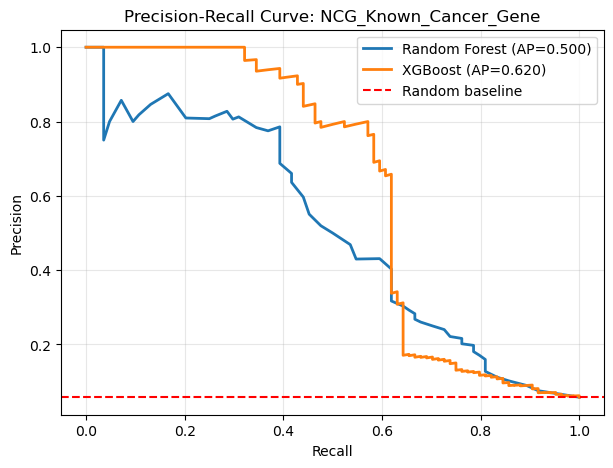

In [11]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [12]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    6580
True      654
Name: count, dtype: int64

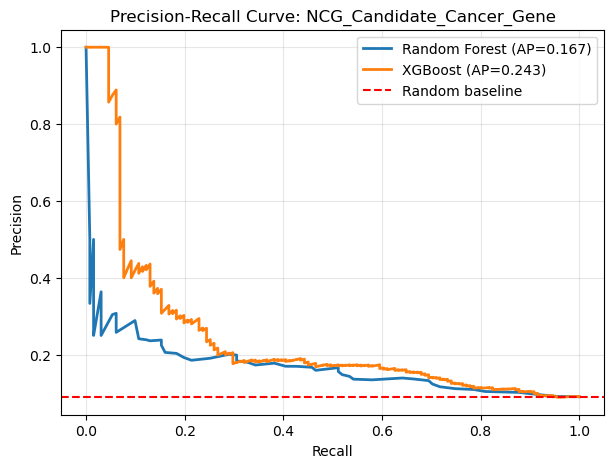

In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [14]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    6901
True      333
Name: count, dtype: int64

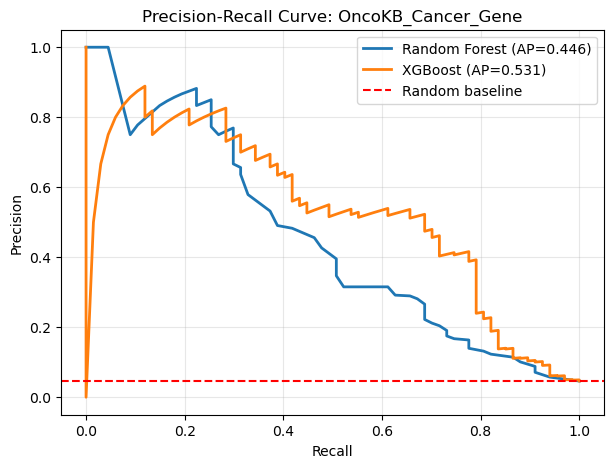

In [15]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [16]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    7067
True      167
Name: count, dtype: int64

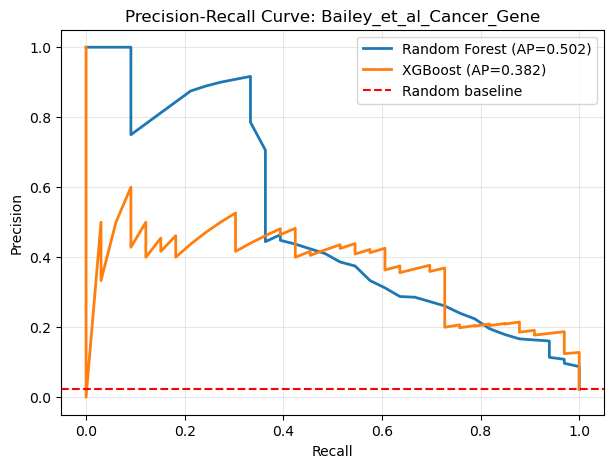

In [17]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')